# ✂️ 03. Divisão Treino, Validação e Teste (Time Series Split)

**Objetivo:** Separar os dados respeitando a cronologia para garantir uma avaliação honesta do modelo e simular o ambiente de produção.

### 🧠 Estratégia de Separação em 3 Etapas
Para simular um ambiente de produção real e evitar *Data Leakage*, dividiremos os dados em três conjuntos cronológicos:

1.  **Treino (Train):** Onde o modelo aprende os padrões (Jan/2013 a Jun/2017).
2.  **Validação (Validation):** Usado durante o treinamento para ajuste de hiperparâmetros e *early stopping* (Jul/2017 a Set/2017).
3.  **Teste (Test):** O "cofre" fechado. O modelo **nunca** vê esses dados durante o desenvolvimento. Usado exclusivamente no notebook `07_final_evaluation` para medir a performance final (Out/2017 a Dez/2017).

### 📅 Datas de Corte  
* **Início Validação:** `2017-07-01`
* **Início Teste:** `2017-10-01`

## 🛠️ Imports e Configurações

### Pacotes 

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.tools import load_config, avaliar_modelo, registrar_metricas


### Configurações gerais

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Caminhos
DATA_PATH = '../data/processed/dados_com_features.csv'    # com sales e sales_log  notebook  02
PATH_PROCESS = '../data/processed'
FILE_MODELAGEM = '../data/processed/dados_modelagem.pkl'  # Treino + Validação (Pickle)
FILE_TESTE = '../data/processed/dados_teste.pkl'          # Teste Final (Pickle)


In [4]:
# 📅 DATAS DE CORTE (DEFINIÇÃO CRÍTICA)
# Teste: Últimos 3 meses do dataset (Out-Dez 2017)
# Validação: 3 meses anteriores ao teste (Jul-Set 2017)

#🚩
config = load_config()
TEST_START_DATE = config['dates']['test_start_date']
VAL_START_DATE = config['dates']['val_start_date']
EXCLUIR_COLUNA_MODELO = config['excluir_colunas_modelo']
ORDENACAO_BASE_BUSCA = config['ordenacao_base_busca']
print(f"Datas: {TEST_START_DATE} | {VAL_START_DATE}")
print(f'Colunas a serem excluidas: {EXCLUIR_COLUNA_MODELO}')


Datas: 2017-10-01 | 2017-07-01
Colunas a serem excluidas: ['date', 'sales', 'id', 'sales_log', 'day_name', 'holiday_name', 'year']


## ⛁ 1. Carga dos Dados Processados

In [5]:
# Carregar dados
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

#🚩
# Ordenação cronológica é vital para séries temporais
df = df.sort_values(by=ORDENACAO_BASE_BUSCA, ascending=[True, True, True]).reset_index(drop=True)

print(f"Dados carregados: {df.shape}")
print(f"Período total: {df['date'].min().date()} até {df['date'].max().date()}")

Dados carregados: (776000, 38)
Período total: 2013-07-02 até 2017-09-30


## ✂️ 2. Executando o Split (Treino | Validação | Teste)


--- Resumo da Divisão ---
🟢 Treino:     730,000 registros (Até 2017-06-30)
🟡 Validação:  46,000 registros (2017-07-01 - 2017-09-30)
🔴 ***Teste Final:0 registros (NaT - NaT)


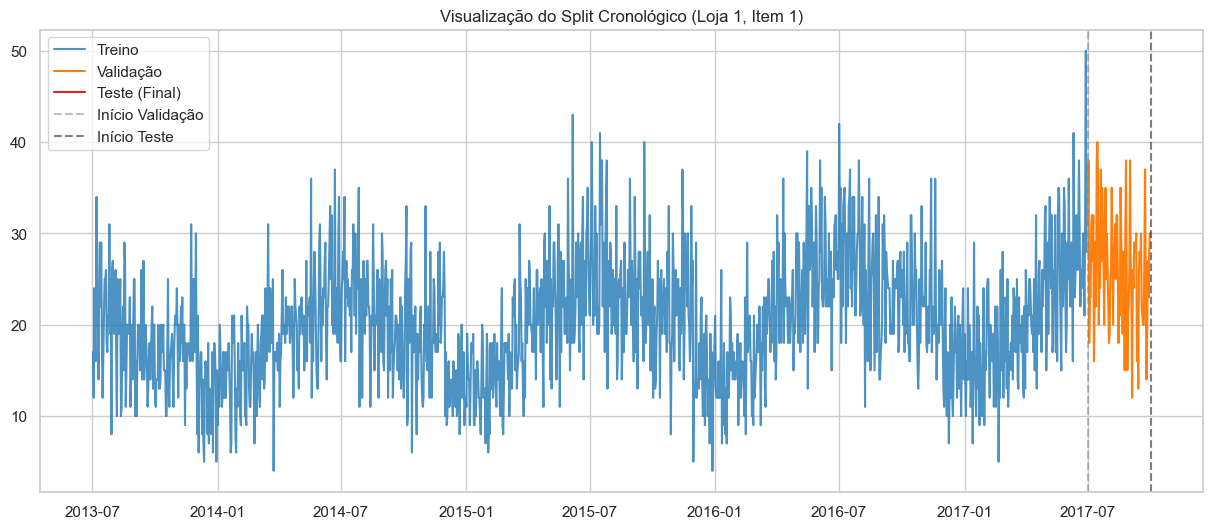

In [6]:
# 1. Separar o Conjunto de Teste (Futuro Final)
test = df[df['date'] >= TEST_START_DATE].copy()
temp_train = df[df['date'] < TEST_START_DATE].copy() # Tudo antes do teste

# 2. Separar Validação e Treino
val = temp_train[temp_train['date'] >= VAL_START_DATE].copy()
train = temp_train[temp_train['date'] < VAL_START_DATE].copy()

print(f"\n--- Resumo da Divisão ---")
print(f"🟢 Treino:     {train.shape[0]:,} registros (Até {train['date'].max().date()})")
print(f"🟡 Validação:  {val.shape[0]:,} registros ({val['date'].min().date()} - {val['date'].max().date()})")
print(f"🔴 ***Teste Final:{test.shape[0]:,} registros ({test['date'].min().date()} - {test['date'].max().date()})")

# --- Visualização do Split ---
# Pegando exemplo da Loja 1, Item 1 para não poluir o gráfico
exemplo = df[(df['store']==1) & (df['item']==1)]

plt.figure(figsize=(15, 6))
plt.plot(exemplo[exemplo['date'] < VAL_START_DATE]['date'], 
         exemplo[exemplo['date'] < VAL_START_DATE]['sales'], 
         label='Treino', color='#1f77b4', alpha=0.8)

plt.plot(exemplo[(exemplo['date'] >= VAL_START_DATE) & (exemplo['date'] < TEST_START_DATE)]['date'], 
         exemplo[(exemplo['date'] >= VAL_START_DATE) & (exemplo['date'] < TEST_START_DATE)]['sales'], 
         label='Validação', color='#ff7f0e')

plt.plot(exemplo[exemplo['date'] >= TEST_START_DATE]['date'], 
         exemplo[exemplo['date'] >= TEST_START_DATE]['sales'], 
         label='Teste (Final)', color='#d62728')

plt.axvline(pd.to_datetime(VAL_START_DATE), color='gray', linestyle='--', alpha=0.5, label='Início Validação')
plt.axvline(pd.to_datetime(TEST_START_DATE), color='black', linestyle='--', alpha=0.5, label='Início Teste')

plt.title('Visualização do Split Cronológico (Loja 1, Item 1)')
plt.legend()
plt.show()

📝 Comentário

Descrição: Nesta etapa do projeto de previsão de demanda, implementei uma divisão cronológica rigorosa dos dados para evitar data leakage (vazamento de dados). Diferente de problemas convencionais de regressão, séries temporais exigem que o modelo seja treinado no passado para prever o futuro.

Treino (Azul): ~776k registros (até Jun/2017) para capturar a sazonalidade anual e tendências de longo prazo.

Validação (Laranja): 3 meses subsequentes para otimização de hiperparâmetros (tunning).

Teste (Vermelho): Os últimos 3 meses do ano (incluindo picos sazonais de fim de ano) para avaliar a capacidade de generalização do modelo em dados nunca vistos ("out-of-time").



## 📏 3. Definição de Métricas e Baseline
Vamos definir a função de avaliação (WAPE, RMSE, MAE) e calcular um Baseline "ingênuo" (Naive Lag 7) no conjunto de validação para ter uma meta mínima.

In [7]:
# O Baseline usa a coluna 'lag_7' (venda da semana passada) como previsão
y_val_log = val['sales_log']
y_pred_baseline = val['lag_7']

# Avaliação na Validação
print("Calculando Baseline na Validação...")


Calculando Baseline na Validação...


In [8]:
#🚩
# >>>Avaliar modelo e registrar métricas para comparar no final 

# Avaliar modelo
metrics = avaliar_modelo(val['sales_log'], val['lag_7'], nome_modelo="Baseline (Naive Sazonal - Lag 7)")

# Registrar metrica
registrar_metricas(
    modelo_nome="Baseline (Naive - Lag7)",
    mae=metrics['mae'],
    rmse=metrics['rmse'],
    wape=metrics['wape'],
    mape=metrics.get('mape', 0), # use get caso não tenha calculado mape antes
    r2=metrics['r2'], 
    notebook="03_train_validation_test_split.ipynb",
    etapa="treinamento"
)

--- Performance: Baseline (Naive - Lag7) ---
MAE:  9.35 (Erro médio em unidades)
RMSE: 12.18 (Penaliza erros grandes)
WAPE: 13.73% (Erro percentual ponderado)
MAPE: 16.08% (Erro médio absoluto)
R²:   0.8738 (Aderência/Variância explicada)
------------------------------
✅ Métricas registradas com sucesso em: c:\Users\Sergio\Desktop\_ESTUDO\_portifolio_full\retail-demand-forecasting\data\metrics_history.csv


📝 Comentário

Tecnicamente, o baseline utilizou a variável alvo em Log (sales_log) para garantir consistência no pipeline de dados com os modelos de ML. Na etapa de avaliação, aplicamos a reversão (expm1) para calcular as métricas em unidades reais, permitindo uma comparação justa e tangível para o negócio.


## 💾 4. Salvando os Arquivos
Vamos salvar dois tipos de arquivos:
1.  **Pickles (.pkl):** Para uso interno nos notebooks Python (preserva tipos de dados).
2.  **CSVs (.csv):** Para uso no notebook final de avaliação (requisito de negócio).

In [9]:
# Definição de Features e Target
# cols_drop = ['sales', 'sales_log', 'date', 'id'] # Colunas que não são input do modelo

#🚩
cols_drop = EXCLUIR_COLUNA_MODELO

features = [c for c in train.columns if c not in cols_drop]

print(f"Total de Features: {len(features)}")

# Pacote para Modelagem (Treino + Validação) ---
# Usado nos notebooks de treinamento (04, 05, 06)
pack_modelagem = {
    'X_train': train[features], 'y_train': train['sales_log'],
    'X_val': val[features],     'y_val': val['sales_log'],
    'features': features
}

# Pacote para Teste Final ---
# DataFrame completo para análise exploratória no final
pack_teste = {
    'df_test': test,
    'X_test': test[features],
    'y_test': test['sales_log']
}

os.makedirs(PATH_PROCESS, exist_ok=True)

# A) Salvando Pickles (Python)
with open(FILE_MODELAGEM, 'wb') as f:
    pickle.dump(pack_modelagem, f)
    
with open(FILE_TESTE, 'wb') as f:
    pickle.dump(pack_teste, f)

# B) Salvando CSVs (Para compatibilidade com notebook 07)
print("Salvando CSVs para o Notebook 07...")
cols_to_save = ['date'] + features
test[cols_to_save].to_csv(os.path.join(PATH_PROCESS, 'X_test.csv'), index=False)
test[['sales_log']].to_csv(os.path.join(PATH_PROCESS, 'y_test.csv'), index=False)

print("✅ Arquivos salvos com sucesso!")
print(f"1. Pickles: {FILE_MODELAGEM}, {FILE_TESTE}")
print(f"2. CSVs: {os.path.join(PATH_PROCESS, 'X_test.csv')}, {os.path.join(PATH_PROCESS, 'y_test.csv')}")

Total de Features: 32
Salvando CSVs para o Notebook 07...
✅ Arquivos salvos com sucesso!
1. Pickles: ../data/processed/dados_modelagem.pkl, ../data/processed/dados_teste.pkl
2. CSVs: ../data/processed\X_test.csv, ../data/processed\y_test.csv


In [10]:
train[features].columns

Index(['store', 'item', 'month', 'day', 'day_of_week', 'day_of_year',
       'is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')

In [11]:
val[features].columns

Index(['store', 'item', 'month', 'day', 'day_of_week', 'day_of_year',
       'is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')